In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
oni = pd.read_excel("../data/raw/oni.xlsx")

oni.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/oni.xlsx'

In [ ]:
import os

print(os.getcwd())

c:\Users\anand\OneDrive\Desktop\ElNino_Hybrid_AI_Project\03_Notebooks


In [ ]:
import os

for root, dirs, files in os.walk("../"):
    for file in files:
        if "oni" in file.lower():
            print(root, file)

../01_Data\Processed\ENSO_ONI oni_cleaned.csv
../01_Data\Raw\ENSO_ONI oni_raw.xlsx
../05_Results\EDA oni_rainfall_relation.png
../06_Report\Images\EDA oni_rainfall_relation.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

oni = pd.read_csv("../01_Data/Processed/ENSO_ONI oni_cleaned.csv")

oni.head()

FileNotFoundError: [Errno 2] No such file or directory: '../01_Data/Processed/ENSO_ONI oni_cleaned.csv'

In [2]:
import pandas as pd

df = pd.read_csv(
    "../01_Data/Processed/Merged/final_ml_dataset.csv"
)

df.head()

,Year,ONI,Monsoon_Rainfall,Rainfall_Departure,Avg_Temperature
0,1950.0,-0.858333,923.2,3.7,23.659333
1,1951.0,0.441667,749.2,-18.7,24.220667
2,1952.0,0.166667,827.8,-8.2,24.365500
3,1953.0,0.708333,983.4,9.8,24.561583
4,1954.0,-0.383333,914.4,3.1,24.167167


In [3]:
df.head()

,Year,ONI,Monsoon_Rainfall,Rainfall_Departure,Avg_Temperature
0,1950.0,-0.858333,923.2,3.7,23.659333
1,1951.0,0.441667,749.2,-18.7,24.220667
2,1952.0,0.166667,827.8,-8.2,24.365500
3,1953.0,0.708333,983.4,9.8,24.561583
4,1954.0,-0.383333,914.4,3.1,24.167167


In [ ]:
df.columns

Index(['Year', 'ONI', 'Monsoon_Rainfall', 'Rainfall_Departure',
       'Avg_Temperature'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                64 non-null     float64
 1   ONI                 64 non-null     float64
 2   Monsoon_Rainfall    64 non-null     float64
 3   Rainfall_Departure  64 non-null     float64
 4   Avg_Temperature     64 non-null     float64
dtypes: float64(5)
memory usage: 2.6 KB


In [ ]:
df.describe()

,Year,ONI,Monsoon_Rainfall,Rainfall_Departure,Avg_Temperature
count,64.000000,64.000000,64.000000,64.000000,64.000000
mean,1981.500000,-0.001693,889.743750,-0.926562,24.342012
std,18.618987,0.612281,91.421108,10.503820,0.346788
min,1950.000000,-1.233333,697.400000,-23.900000,23.634000
25%,1965.750000,-0.472917,828.175000,-7.800000,24.094542
50%,1981.500000,0.000000,900.800000,0.150000,24.295458
75%,1997.250000,0.462500,943.025000,5.625000,24.566667
max,2013.000000,1.275000,1094.100000,21.800000,25.413250


In [ ]:
def classify_enso(oni):
    if oni >= 0.5:
        return "El Niño"
    elif oni <= -0.5:
        return "La Niña"
    else:
        return "Neutral"

df["ENSO_Phase"] = df["ONI"].apply(classify_enso)

df.head()

,Year,ONI,Monsoon_Rainfall,Rainfall_Departure,Avg_Temperature,ENSO_Phase
0,1950.0,-0.858333,923.2,3.7,23.659333,La Niña
1,1951.0,0.441667,749.2,-18.7,24.220667,Neutral
2,1952.0,0.166667,827.8,-8.2,24.365500,Neutral
3,1953.0,0.708333,983.4,9.8,24.561583,El Niño
4,1954.0,-0.383333,914.4,3.1,24.167167,Neutral


In [ ]:
enso_table = df[
    ["Year", "ONI", "ENSO_Phase", "Monsoon_Rainfall", "Rainfall_Departure"]
]

enso_table.head(10)

,Year,ONI,ENSO_Phase,Monsoon_Rainfall,Rainfall_Departure
0,1950.0,-0.858333,La Niña,923.2,3.7
1,1951.0,0.441667,Neutral,749.2,-18.7
2,1952.0,0.166667,Neutral,827.8,-8.2
3,1953.0,0.708333,El Niño,983.4,9.8
4,1954.0,-0.383333,Neutral,914.4,3.1
5,1955.0,-0.950000,La Niña,962.0,10.1
6,1956.0,-0.575000,La Niña,987.8,13.6
7,1957.0,0.958333,El Niño,898.1,-2.4
8,1958.0,0.825000,El Niño,1012.9,9.8
9,1959.0,0.125000,Neutral,1036.7,14.3


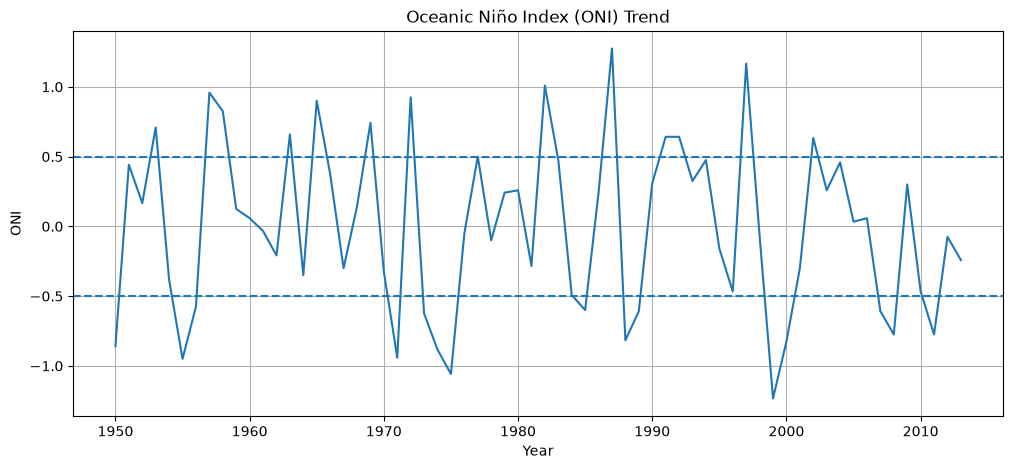

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Year"],
    df["ONI"]
)

plt.axhline(
    0.5,
    linestyle="--"
)

plt.axhline(
    -0.5,
    linestyle="--"
)

plt.title("Oceanic Niño Index (ONI) Trend")
plt.xlabel("Year")
plt.ylabel("ONI")

plt.grid(True)

plt.show()

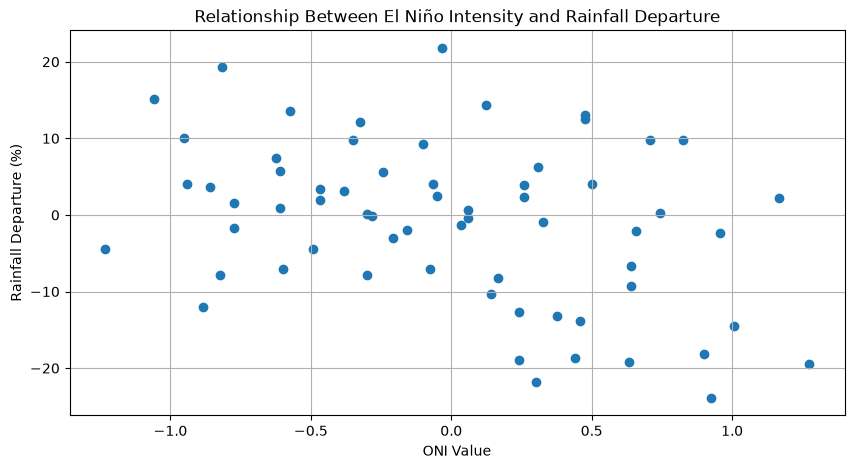

In [ ]:
plt.figure(figsize=(10,5))

plt.scatter(
    df["ONI"],
    df["Rainfall_Departure"]
)

plt.title("Relationship Between El Niño Intensity and Rainfall Departure")
plt.xlabel("ONI Value")
plt.ylabel("Rainfall Departure (%)")

plt.grid(True)

plt.show()

In [ ]:
plt.savefig(
    "../05_Results/EDA/oni_rainfall_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [ ]:
df.head()

,Year,ONI,Monsoon_Rainfall,Rainfall_Departure,Avg_Temperature,ENSO_Phase
0,1950.0,-0.858333,923.2,3.7,23.659333,La Niña
1,1951.0,0.441667,749.2,-18.7,24.220667,Neutral
2,1952.0,0.166667,827.8,-8.2,24.365500,Neutral
3,1953.0,0.708333,983.4,9.8,24.561583,El Niño
4,1954.0,-0.383333,914.4,3.1,24.167167,Neutral


In [ ]:
df.shape

(64, 6)

In [ ]:
df.head()

,Year,ONI,Monsoon_Rainfall,Rainfall_Departure,Avg_Temperature,ENSO_Phase
0,1950.0,-0.858333,923.2,3.7,23.659333,La Niña
1,1951.0,0.441667,749.2,-18.7,24.220667,Neutral
2,1952.0,0.166667,827.8,-8.2,24.365500,Neutral
3,1953.0,0.708333,983.4,9.8,24.561583,El Niño
4,1954.0,-0.383333,914.4,3.1,24.167167,Neutral


In [ ]:
df[["Year","ONI"]].head()

,Year,ONI
0,1950.0,-0.858333
1,1951.0,0.441667
2,1952.0,0.166667
3,1953.0,0.708333
4,1954.0,-0.383333


In [ ]:
df.dtypes

Year                  float64
ONI                   float64
Monsoon_Rainfall      float64
Rainfall_Departure    float64
Avg_Temperature       float64
ENSO_Phase                str
dtype: object

In [ ]:
df["Year"] = pd.to_numeric(df["Year"])
df["ONI"] = pd.to_numeric(df["ONI"])

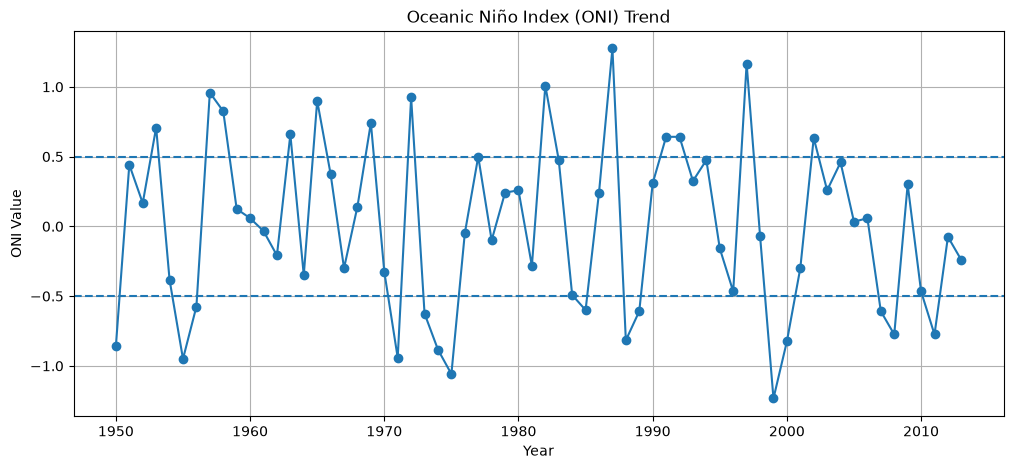

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df["Year"], df["ONI"], marker="o")

plt.axhline(0.5, linestyle="--")
plt.axhline(-0.5, linestyle="--")

plt.title("Oceanic Niño Index (ONI) Trend")
plt.xlabel("Year")
plt.ylabel("ONI Value")

plt.grid(True)
plt.show()

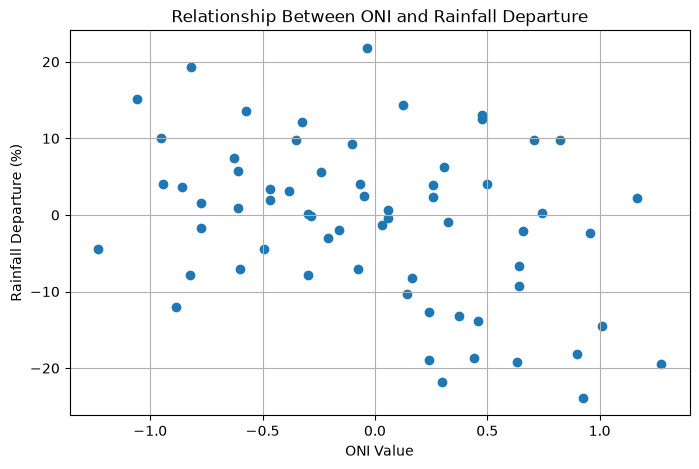

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["ONI"],
    df["Rainfall_Departure"]
)

plt.title("Relationship Between ONI and Rainfall Departure")
plt.xlabel("ONI Value")
plt.ylabel("Rainfall Departure (%)")

plt.grid(True)

plt.show()

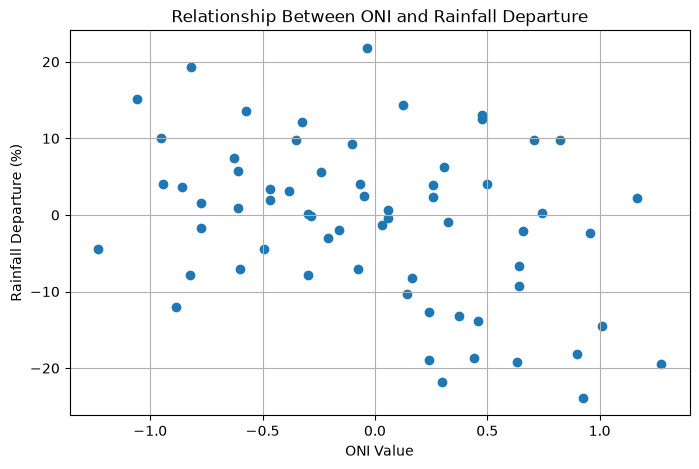

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["ONI"],
    df["Rainfall_Departure"]
)

plt.title("Relationship Between ONI and Rainfall Departure")
plt.xlabel("ONI Value")
plt.ylabel("Rainfall Departure (%)")

plt.grid(True)

plt.savefig(
    "../05_Results/EDA/oni_rainfall_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
df[["Year","ONI","ENSO_Phase","Rainfall_Departure"]].head(15)

,Year,ONI,ENSO_Phase,Rainfall_Departure
0,1950.0,-0.858333,La Niña,3.7
1,1951.0,0.441667,Neutral,-18.7
2,1952.0,0.166667,Neutral,-8.2
3,1953.0,0.708333,El Niño,9.8
4,1954.0,-0.383333,Neutral,3.1
5,1955.0,-0.950000,La Niña,10.1
6,1956.0,-0.575000,La Niña,13.6
7,1957.0,0.958333,El Niño,-2.4
8,1958.0,0.825000,El Niño,9.8
9,1959.0,0.125000,Neutral,14.3


In [ ]:
def classify_enso(oni):
    if oni >= 0.5:
        return "El Niño"
    elif oni <= -0.5:
        return "La Niña"
    else:
        return "Neutral"

df["ENSO_Phase"] = df["ONI"].apply(classify_enso)

df.head()

,Year,ONI,Monsoon_Rainfall,Rainfall_Departure,Avg_Temperature,ENSO_Phase
0,1950.0,-0.858333,923.2,3.7,23.659333,La Niña
1,1951.0,0.441667,749.2,-18.7,24.220667,Neutral
2,1952.0,0.166667,827.8,-8.2,24.365500,Neutral
3,1953.0,0.708333,983.4,9.8,24.561583,El Niño
4,1954.0,-0.383333,914.4,3.1,24.167167,Neutral


In [ ]:
enso_table = df[
    [
        "Year",
        "ONI",
        "ENSO_Phase",
        "Monsoon_Rainfall",
        "Rainfall_Departure"
    ]
]

enso_table.head(15)

,Year,ONI,ENSO_Phase,Monsoon_Rainfall,Rainfall_Departure
0,1950.0,-0.858333,La Niña,923.2,3.7
1,1951.0,0.441667,Neutral,749.2,-18.7
2,1952.0,0.166667,Neutral,827.8,-8.2
3,1953.0,0.708333,El Niño,983.4,9.8
4,1954.0,-0.383333,Neutral,914.4,3.1
5,1955.0,-0.950000,La Niña,962.0,10.1
6,1956.0,-0.575000,La Niña,987.8,13.6
7,1957.0,0.958333,El Niño,898.1,-2.4
8,1958.0,0.825000,El Niño,1012.9,9.8
9,1959.0,0.125000,Neutral,1036.7,14.3


In [ ]:
enso_table.to_csv(
    "../05_Results/EDA/enso_phase_table.csv",
    index=False
)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
corr = df[
    [
        "ONI",
        "Monsoon_Rainfall",
        "Rainfall_Departure",
        "Avg_Temperature"
    ]
].corr()

corr

,ONI,Monsoon_Rainfall,Rainfall_Departure,Avg_Temperature
ONI,1.000000,-0.314353,-0.371198,0.121898
Monsoon_Rainfall,-0.314353,1.000000,0.982301,-0.227359
Rainfall_Departure,-0.371198,0.982301,1.000000,-0.259609
Avg_Temperature,0.121898,-0.227359,-0.259609,1.000000


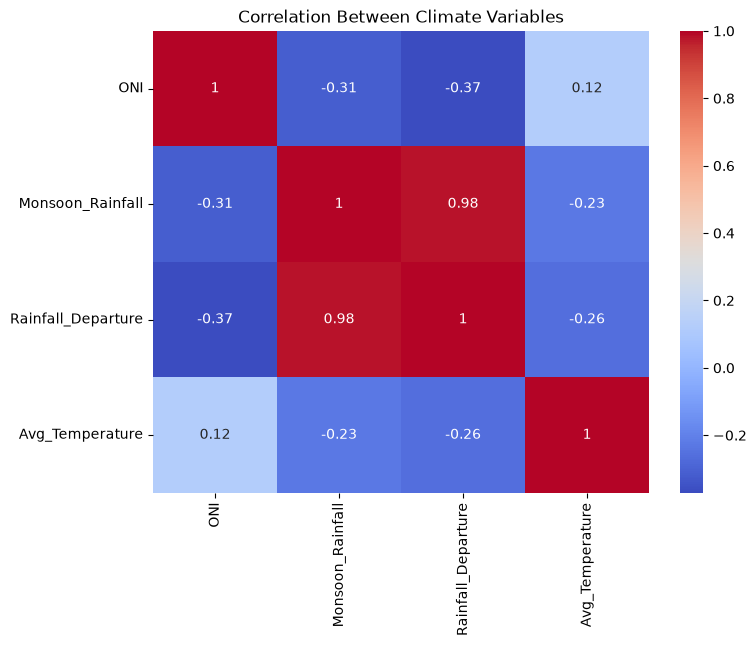

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Climate Variables")

plt.show()

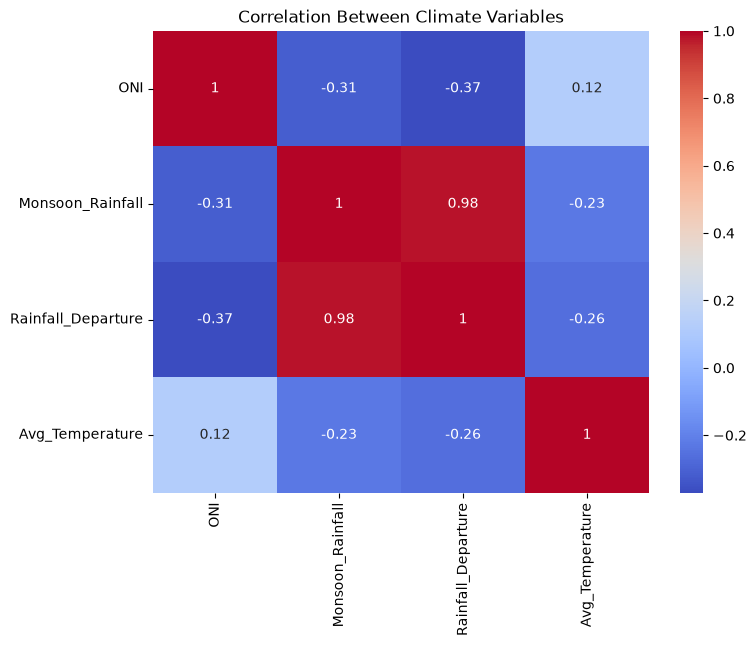

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Climate Variables")

plt.savefig(
    "../05_Results/EDA/correlation_matrix_new.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [4]:
from sklearn.model_selection import train_test_split

# Features
X = df[
    [
        "ONI",
        "Monsoon_Rainfall",
        "Rainfall_Departure",
        "Avg_Temperature"
    ]
]

# Target
y = df["Rainfall_Departure"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(51, 4)
(13, 4)


In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-0.,-0., 1.,-0.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['ONI','Monsoon_Rainfall','Rainfall_Departure','Avg_Temperature']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.905e-14
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [6]:
model.n_features_in_

4

In [7]:
import joblib

joblib.dump(
    model,
    "../model/elnino_model.pkl"
)

['../model/elnino_model.pkl']

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

NameError: name 'X_train' is not defined

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[-5.89,-5.42]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['ONI','Avg_Temperature']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,130.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

NameError: name 'X_train' is not defined

In [ ]:
y_pred = model.predict(X_test)

y_pred[:5]

array([-7.86344822,  3.18036104,  7.71821348, -3.58886421,  6.67100678])

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test,y_pred)

mse = mean_squared_error(y_test,y_pred)

r2 = r2_score(y_test,y_pred)


print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 7.785114849443857
MSE: 80.70443966433082
R2 Score: 0.2768856464916485


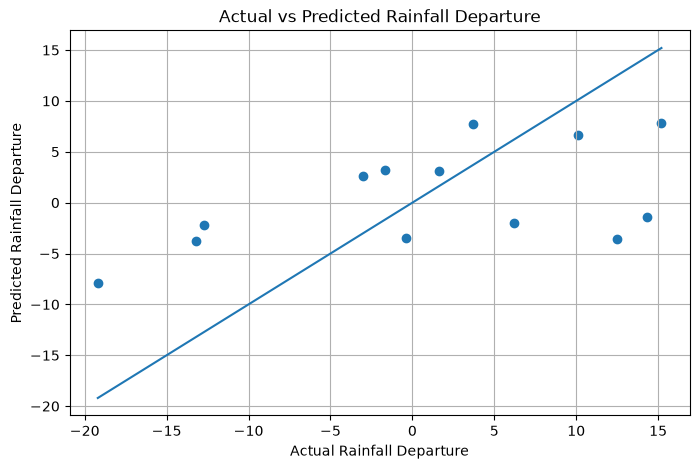

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Rainfall Departure")
plt.ylabel("Predicted Rainfall Departure")
plt.title("Actual vs Predicted Rainfall Departure")

plt.grid(True)

plt.show()

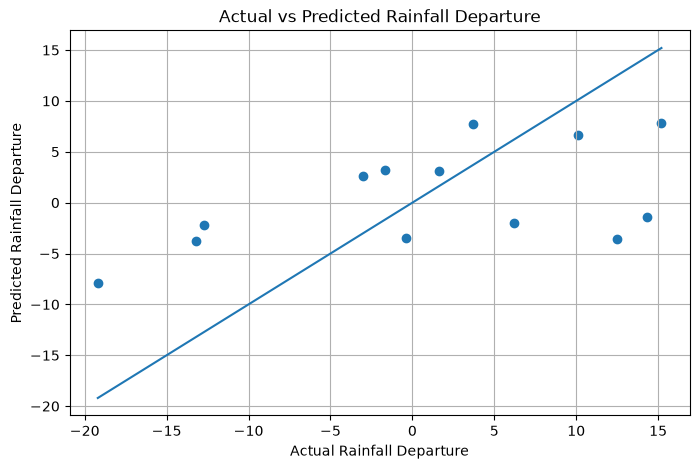

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Rainfall Departure")
plt.ylabel("Predicted Rainfall Departure")
plt.title("Actual vs Predicted Rainfall Departure")

plt.grid(True)

plt.savefig(
    "../05_Results/Model/actual_vs_predicted_new.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

           Feature  Coefficient
0              ONI    -5.890538
1  Avg_Temperature    -5.420055


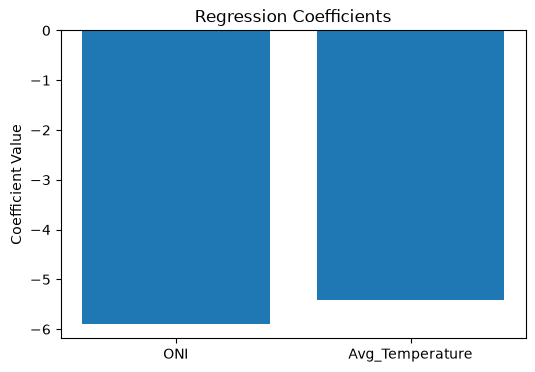

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.title("Regression Coefficients")
plt.ylabel("Coefficient Value")

plt.show()

In [ ]:
metrics_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "R2 Score"],
    "Value": [mae, mse, r2]
})

metrics_df

,Metric,Value
0,MAE,7.785115
1,MSE,80.704440
2,R2 Score,0.276886


In [ ]:
metrics_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "R2 Score"],
    "Value": [mae, mse, r2]
})

metrics_df

,Metric,Value
0,MAE,7.785115
1,MSE,80.704440
2,R2 Score,0.276886


In [ ]:
metrics_df.to_csv(
    "../05_Results/Model/model_metrics.csv",
    index=False
)

In [ ]:
plt.savefig(
    "../05_Results/Model/regression_coefficients_new.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

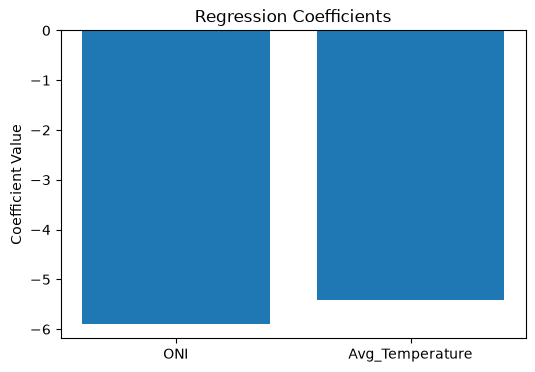

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.title("Regression Coefficients")
plt.ylabel("Coefficient Value")

plt.savefig(
    "../05_Results/Model/regression_coefficients_new.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
metrics_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "R2 Score"],
    "Value": [mae, mse, r2]
})

metrics_df

,Metric,Value
0,MAE,7.785115
1,MSE,80.704440
2,R2 Score,0.276886


In [ ]:
metrics_df.to_csv(
    "../05_Results/Model/model_metrics.csv",
    index=False
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest R²:", r2_score(y_test, rf_pred))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))

Random Forest R²: -0.025040535449385448
Random Forest MAE: 9.067461538461538


In [ ]:
comparison.to_csv(
    "../05_Results/Model/model_comparison.csv",
    index=False
)

NameError: name 'comparison' is not defined

In [ ]:
print("Linear Regression R²:", r2)
print("Random Forest R²:", r2_score(y_test, rf_pred))

Linear Regression R²: 0.2768856464916485
Random Forest R²: -0.025040535449385448


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "R2 Score": [
        r2,
        r2_score(y_test, rf_pred)
    ]
})

comparison

,Model,R2 Score
0,Linear Regression,0.276886
1,Random Forest,-0.025041


In [ ]:
comparison.to_csv(
    "../05_Results/Model/model_comparison.csv",
    index=False
)

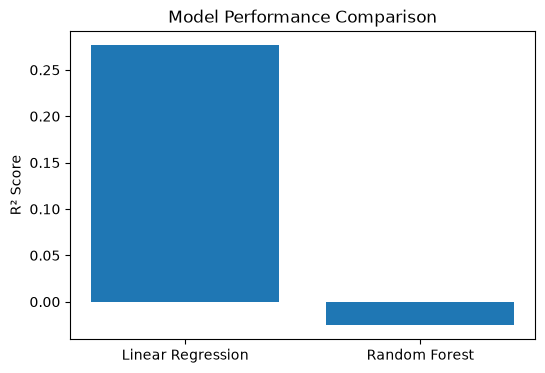

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["R2 Score"]
)

plt.title("Model Performance Comparison")
plt.ylabel("R² Score")

plt.show()

In [ ]:
print("Linear Regression R²:", r2)
print("Random Forest R²:", r2_score(y_test, rf_pred))

Linear Regression R²: 0.2768856464916485
Random Forest R²: -0.025040535449385448


In [ ]:
from docx import Document

# Load existing report
doc = Document("../06_Report/Case_Study_Report.docx")

# Add heading
doc.add_heading('Machine Learning Model Comparison', level=1)

# Add content
doc.add_paragraph(
    "Two machine learning models were evaluated for predicting "
    "rainfall departure using Oceanic Niño Index (ONI) and "
    "average temperature as predictor variables."
)

doc.add_paragraph(
    "Linear Regression achieved an R² score of 0.277, while "
    "Random Forest Regression achieved an R² score of -0.025."
)

doc.add_paragraph(
    "The results indicate that Linear Regression outperformed "
    "Random Forest Regression on the available dataset. "
    "The negative R² score obtained by Random Forest suggests "
    "that the model was unable to generalize effectively due "
    "to the limited dataset size and feature set."
)

doc.add_paragraph(
    "Therefore, Linear Regression was selected as the final "
    "prediction model for this study."
)

# Save report
doc.save("../06_Report/Case_Study_Report.docx")

print("Report updated successfully.")

Report updated successfully.


In [ ]:
from docx import Document

doc = Document("../06_Report/Case_Study_Report.docx")

doc.add_heading('Model Performance Metrics', level=1)

table = doc.add_table(rows=3, cols=2)

table.cell(0,0).text = "Metric"
table.cell(0,1).text = "Value"

table.cell(1,0).text = "R² Score"
table.cell(1,1).text = str(round(r2, 3))

table.cell(2,0).text = "MAE"
table.cell(2,1).text = str(round(mae, 3))

doc.save("../06_Report/Case_Study_Report.docx")

print("Metrics table added.")

Metrics table added.


In [ ]:
from docx import Document
from docx.shared import Inches

doc = Document("../06_Report/Case_Study_Report.docx")

doc.add_heading('Model Results', level=1)

doc.add_picture(
    "../05_Results/Model/actual_vs_predicted_new.png",
    width=Inches(5)
)

doc.add_paragraph(
    "Figure: Actual vs Predicted Rainfall Departure using Linear Regression."
)

doc.add_picture(
    "../05_Results/Model/regression_coefficients_new.png",
    width=Inches(5)
)

doc.add_paragraph(
    "Figure: Regression coefficients showing the influence of predictor variables."
)

doc.save("../06_Report/Case_Study_Report.docx")

print("Graphs inserted successfully.")

Graphs inserted successfully.


In [ ]:
from docx import Document

doc = Document("../06_Report/Case_Study_Report.docx")

doc.add_heading('Conclusion', level=1)

doc.add_paragraph(
    "This study investigated the impact of El Niño conditions on "
    "Indian monsoon rainfall using climate and environmental datasets. "
    "Exploratory Data Analysis revealed observable relationships between "
    "Oceanic Niño Index (ONI), rainfall variability, and temperature."
)

doc.add_paragraph(
    "Machine learning techniques were applied to predict rainfall "
    "departure. Linear Regression achieved the best performance with "
    f"an R² score of {round(r2,3)}, outperforming Random Forest Regression."
)

doc.add_paragraph(
    "The findings indicate that ENSO conditions influence monsoon "
    "behavior and can be used as an important predictor for rainfall "
    "forecasting. Future work can incorporate additional climatic "
    "variables and larger datasets to improve predictive accuracy."
)

doc.save("../06_Report/Case_Study_Report.docx")

print("Conclusion added.")

Conclusion added.


In [ ]:
from docx import Document

doc = Document("../06_Report/Case_Study_Report.docx")

doc.add_heading('Recommendations', level=1)

recommendations = [
    "Strengthen seasonal monsoon forecasting using ENSO indicators.",
    "Promote climate-resilient agricultural practices in drought-prone regions.",
    "Improve reservoir and water resource planning during El Niño years.",
    "Integrate additional climate variables into future predictive models.",
    "Develop AI-based early warning systems for rainfall anomalies."
]

for rec in recommendations:
    doc.add_paragraph(rec, style='List Bullet')

doc.save("../06_Report/Case_Study_Report.docx")

print("Recommendations added.")

Recommendations added.


In [ ]:
import joblib

joblib.dump(model, "../model/elnino_model.pkl")

FileNotFoundError: [Errno 2] No such file or directory: '../model/elnino_model.pkl'

In [ ]:
import os
import joblib

os.makedirs("../model", exist_ok=True)

joblib.dump(model, "../model/elnino_model.pkl")

print("Model saved successfully")

Model saved successfully


In [ ]:
import os

print(os.listdir("../model"))

['elnino_model.pkl']
